# Implementation of  PCA using Python. Use the iris data set.


## a) Import Libraries

In [14]:
# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

import numpy as np

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import IRIS loader 

from sklearn.datasets import load_iris

# Import StandardScaler to put pixel features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import PCA (Principal Component Analysis) for linear dimensionality reduction
from sklearn.decomposition import PCA

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


### b) Import and standardize data

### Load Dataset

In [6]:
Iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

Iris_df['target'] = iris.target

Iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
Iris_df.shape

(150, 5)

### Split Dataset - Separate Features and Target

In [10]:
X = iris.data
y = iris.target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


### Standardize the Features

#### PCA is affected by scale, so standardization is necessary.

In [15]:
# Standardize data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


## c) PCA execution and Project to 2D

### PCA (Principal Component Analysis) (PCA)
- Type: Linear projection — finds directions of maximum variance
- Output: New axes (principal components) ranked by variance explained
- Key hyperparameters: n_components, random_state
- Inverse transform: Reconstruct approximate original pixels from reduced space

In [18]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['target'] = y

In [20]:
# Variance explained by first two components
variance_2d = variance_ratio[:2].sum()

print(f"Variance retained by first 2 principal components: {variance_2d:.2%}")

Variance retained by first 2 principal components: 95.81%


Explained Variance Ratio:
[0.72962445 0.22850762]


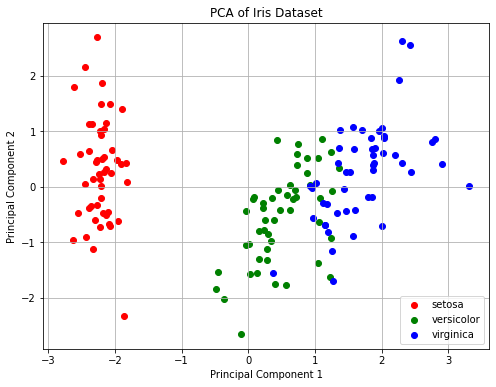

In [19]:
# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']

for i, color in zip(range(3), colors):
    plt.scatter(
        pca_df[pca_df['target']==i]['PC1'],
        pca_df[pca_df['target']==i]['PC2'],
        color=color,
        label=iris.target_names[i]
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True)

plt.show()

### PCA successfully reduced the Iris dataset from 4 features to 2 principal components, while retaining approximately 95% of the dataset's variance, making visualization and analysis easier without significant information loss.